# Análisis del portafolio — Lab 02 · Equipo 3

Solo carga `results/` y grafica con `src/plots.py`. Parte: P4.

In [1]:
import pickle
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS = Path("..") / "results" / "portafolio.pkl"
FIGURES = Path("..") / "docs" / "figuras"
pd.set_option("display.width", 160)

with open(RESULTS, "rb") as archivo:
    resultados = pickle.load(archivo)

In [2]:
display(resultados["weight_stability"].round(4))

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,mean_std,n_reviews
sample,0.0192,0.0223,0.0151,0.0172,0.0297,0.0123,0.0908,0.0131,0.0275,48
ewma,0.0204,0.0225,0.0154,0.0176,0.0277,0.0125,0.0905,0.0125,0.0274,48
ledoit_wolf,0.0178,0.0191,0.0113,0.0163,0.0266,0.0111,0.0706,0.0114,0.0230,48


,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,spread,ann_vol
risk_parity,0.1250,0.125,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.0000,0.1659
equal,0.1303,0.117,0.1336,0.2365,0.0871,0.1483,0.0162,0.1309,0.2206,0.2218


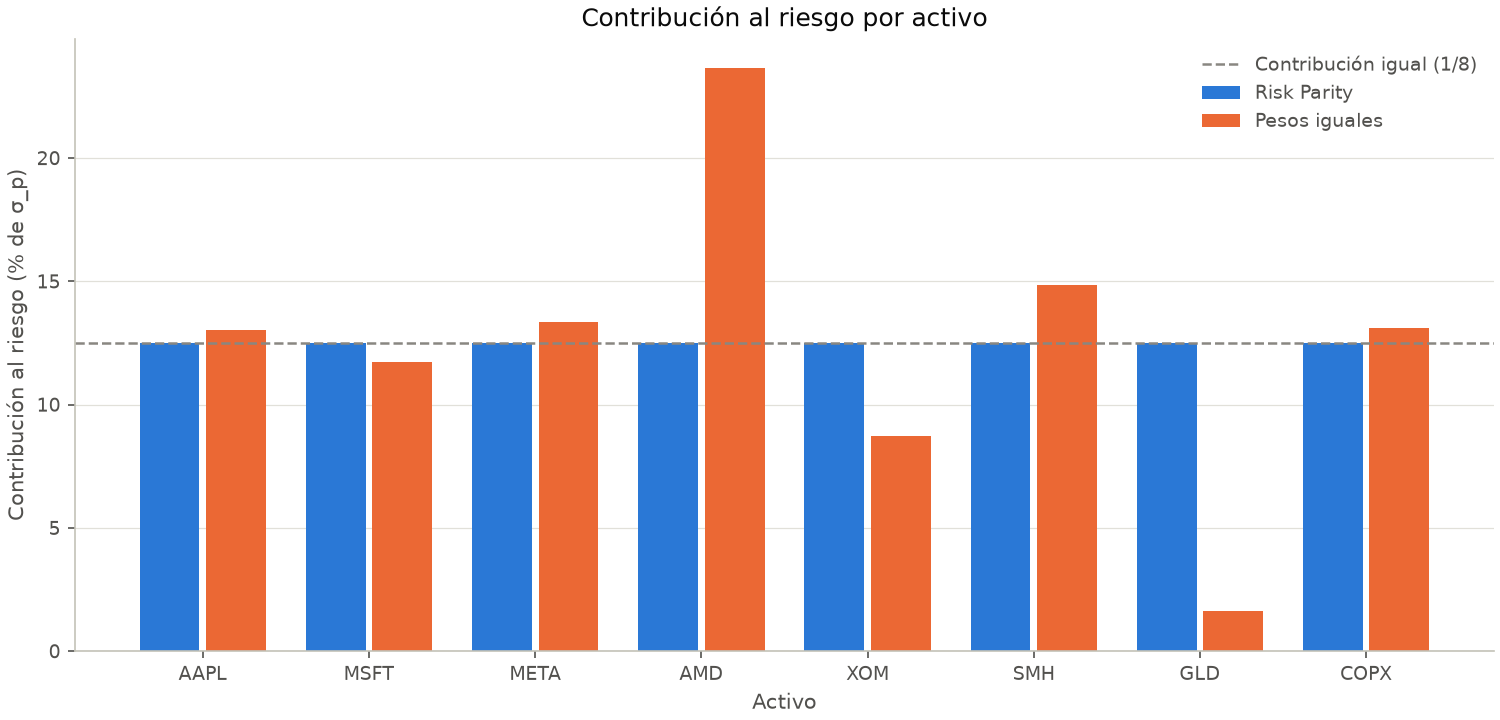

In [3]:
display(resultados["risk_contributions"].round(4))
display(Image(filename=FIGURES / "portafolio_contribuciones_riesgo.png"))

In [4]:
columnas = ["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown", "n_trades"]
display(resultados["performance"]["train"][columnas].round(3))

,ann_return,ann_vol,sharpe,calmar,max_drawdown,n_trades
risk_parity,0.006,0.049,-0.075,0.073,-0.082,375
equal,0.016,0.065,0.111,0.162,-0.099,375
AAPL,0.217,0.242,0.888,0.922,-0.236,45
MSFT,-0.078,0.198,-0.366,-0.189,-0.414,47
META,-0.063,0.285,-0.122,-0.187,-0.337,47
AMD,0.032,0.407,0.252,0.056,-0.575,56
XOM,0.083,0.242,0.405,0.206,-0.404,45
SMH,-0.074,0.233,-0.259,-0.223,-0.330,43
GLD,-0.044,0.087,-0.601,-0.236,-0.186,48
COPX,0.158,0.257,0.655,0.523,-0.302,49


,frequency,band,n_rebalances,turnover,gross_return,total_cost,net_return,n_trades
0,W,0.000,209,0.5999,0.1204,88874.6187,0.0315,375
1,W,0.025,90,0.4852,0.1180,88770.8885,0.0292,375
2,W,0.050,46,0.3815,0.1133,88422.3851,0.0249,375
3,W,0.100,22,0.3267,0.1126,88289.9511,0.0243,375
4,W,0.200,7,0.1909,0.0922,86915.2697,0.0053,375
5,M,0.000,48,0.3817,0.1161,88865.2127,0.0272,375
6,M,0.025,40,0.3678,0.1150,88757.4760,0.0262,375
7,M,0.050,29,0.3362,0.1125,88640.0309,0.0239,375
8,M,0.100,18,0.3018,0.1076,88452.6071,0.0192,375
9,M,0.200,7,0.1960,0.0923,87372.8822,0.0049,375


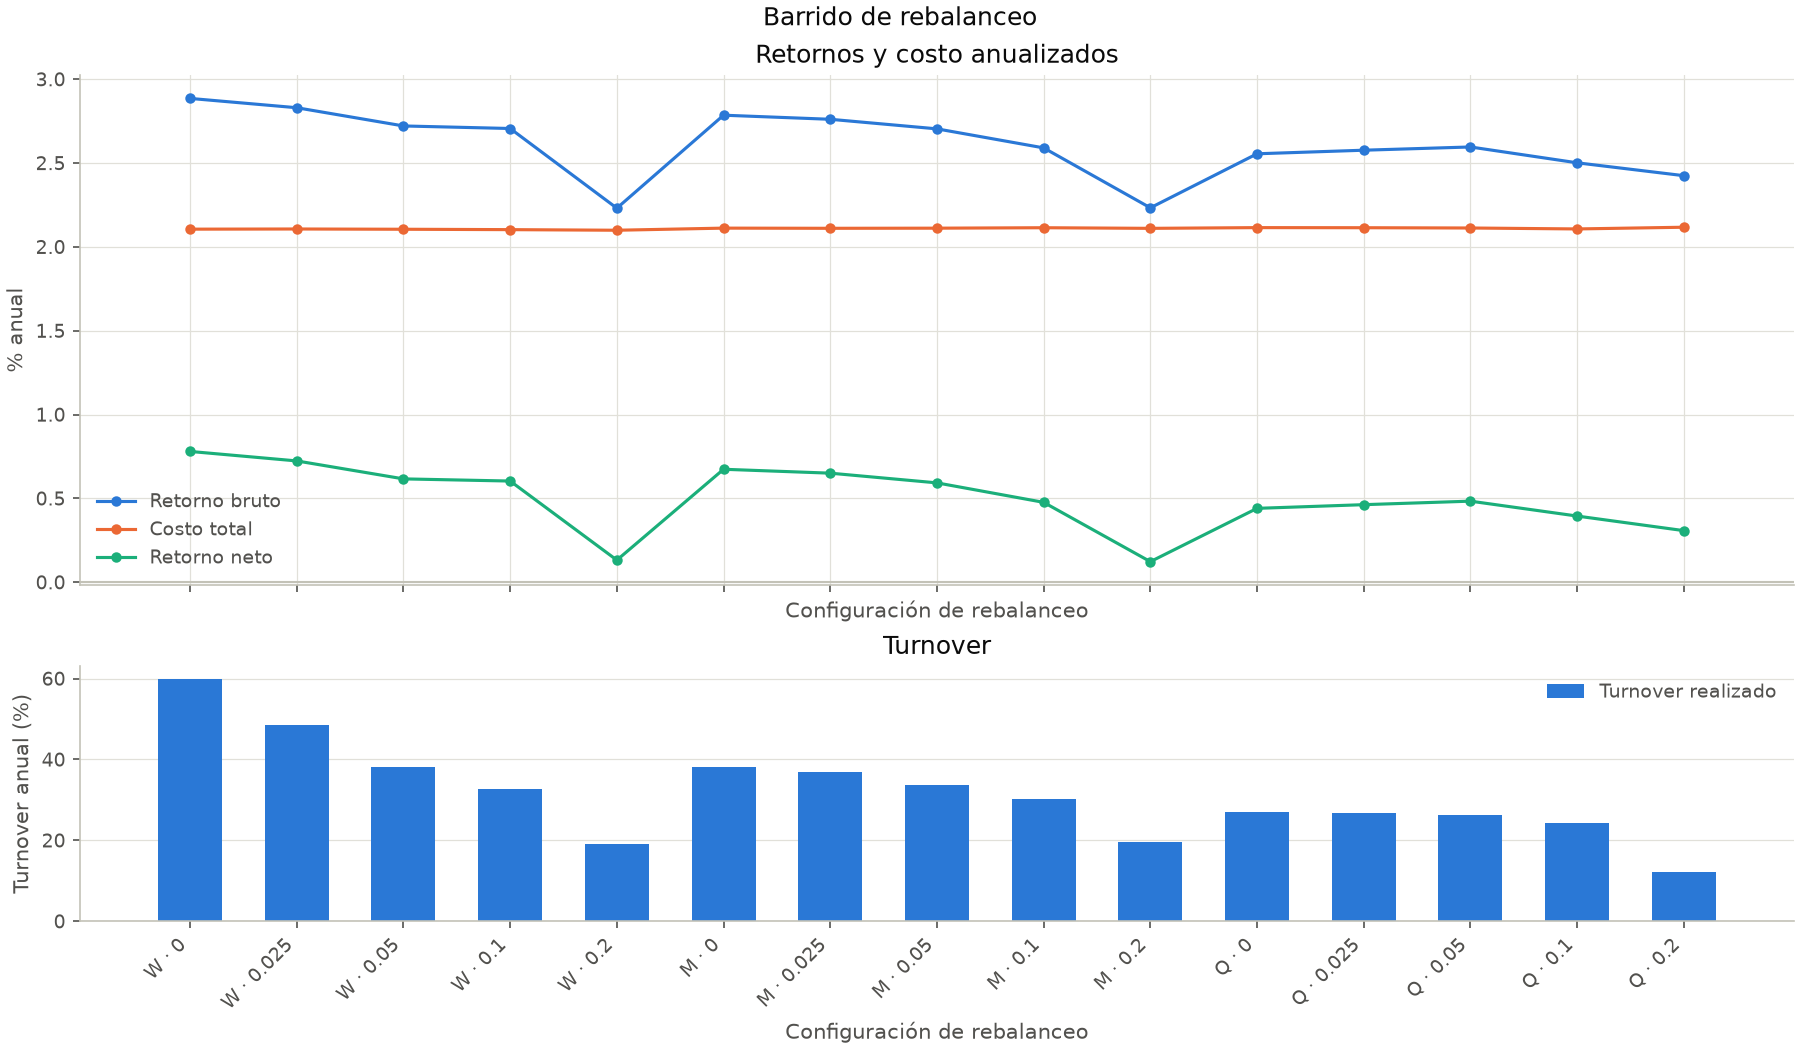

In [5]:
display(resultados["sweep"]["train"].round(4))
display(Image(filename=FIGURES / "portafolio_barrido_rebalanceo.png"))

## Limitaciones

- Estas tablas son de **train con θ base** (SPEC punto 2), sin walk-forward. Los resultados finales
  (walk-forward, validation y test, Risk Parity contra pesos iguales y contra cada activo) están en
  `notebooks/resultados.ipynb`.
- El estimador (Ledoit-Wolf), la frecuencia (mensual) y δ = 0.05 se confirmaron en la corrida única de
  validation (SPEC_portafolio v0.6).
- El rebalanceo solo cambia el tamaño de las entradas nuevas (`resize_on_rebalance=False`), por eso el
  número de operaciones es igual en todo el barrido. Su costo se estima ex post con el turnover de los
  pesos.
- Los costos del barrido vienen sobre todo de las operaciones de señal, no del rebalanceo.
- Cada entrada usa todo su capital asignado C_i = |w^target| · Equity (SPEC punto 5, v1.4). Como
  Σ|w^target| ≤ 1 y la fuerza y m(régimen) lo reducen, la exposición media queda alrededor de 30%.